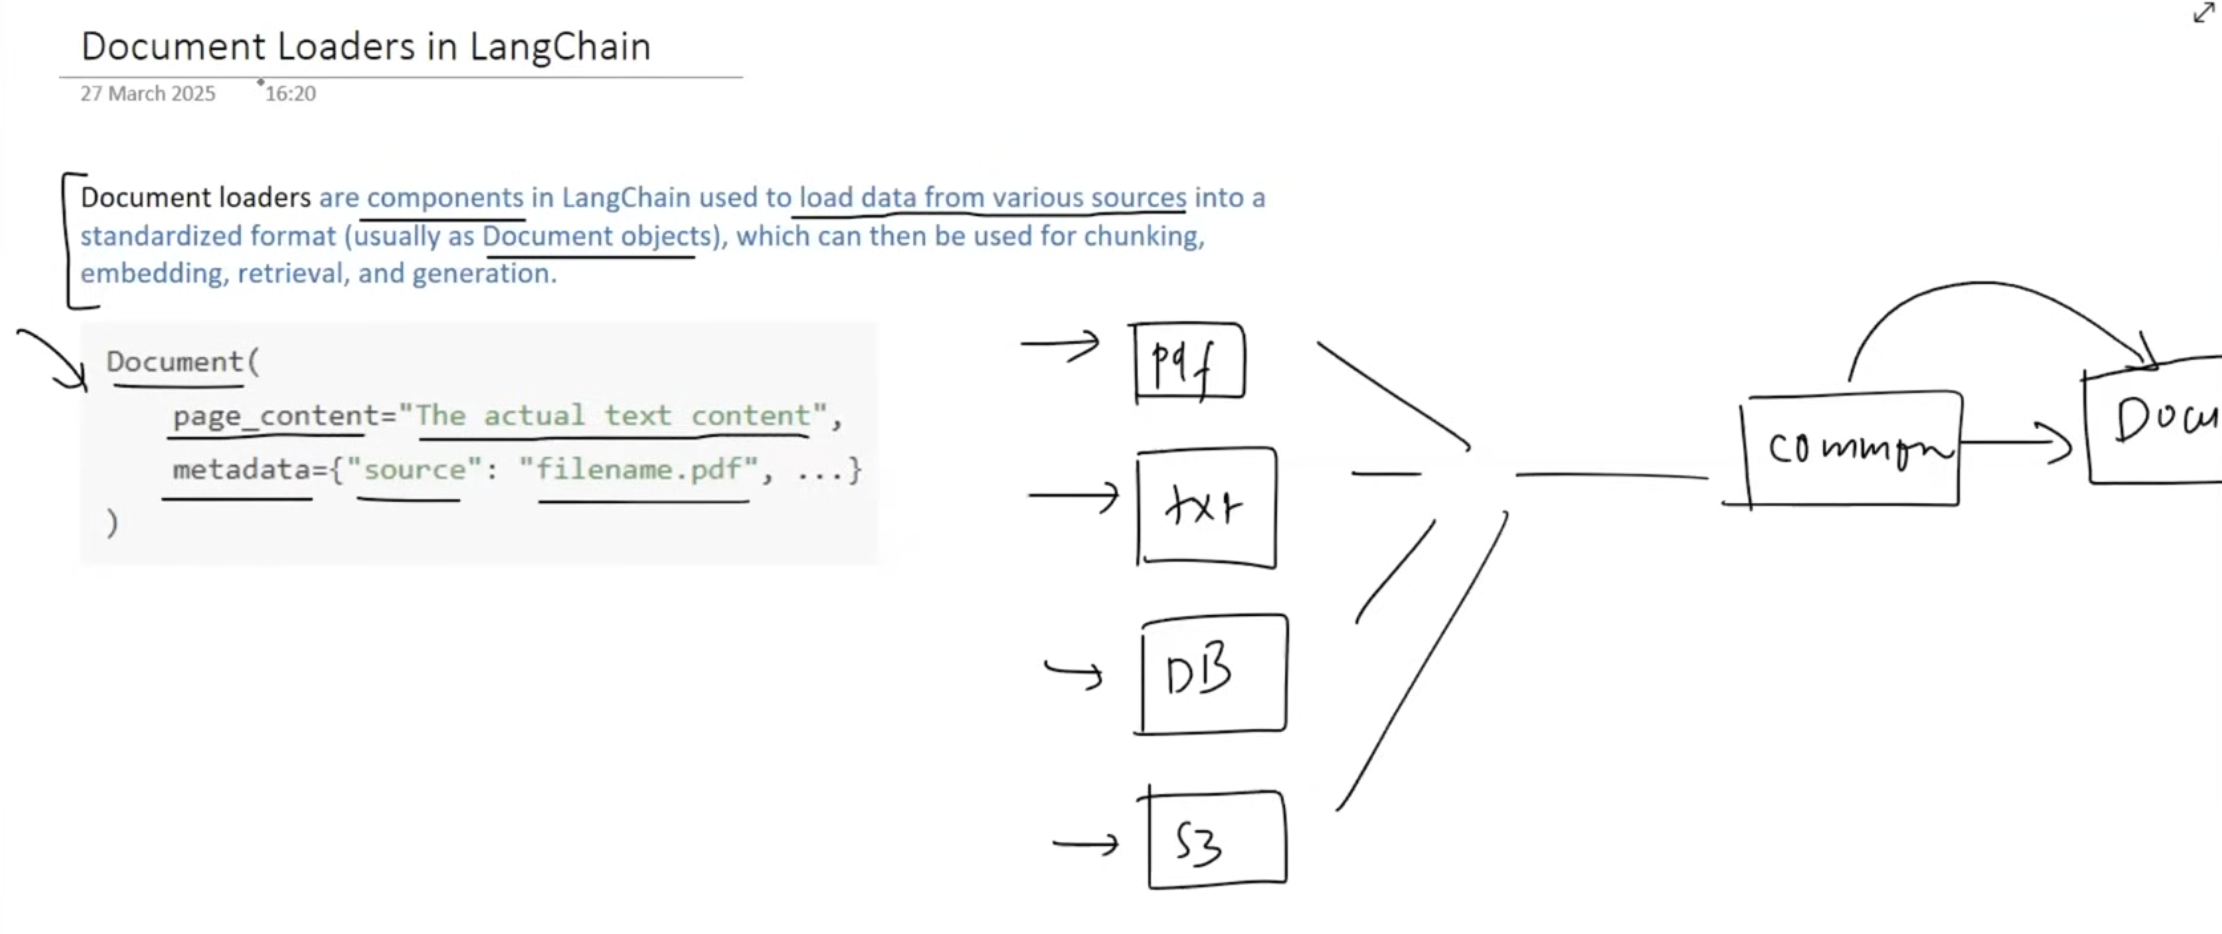

<h1 style="color:rgb(255, 98, 0);">1. Text Loader</h1>

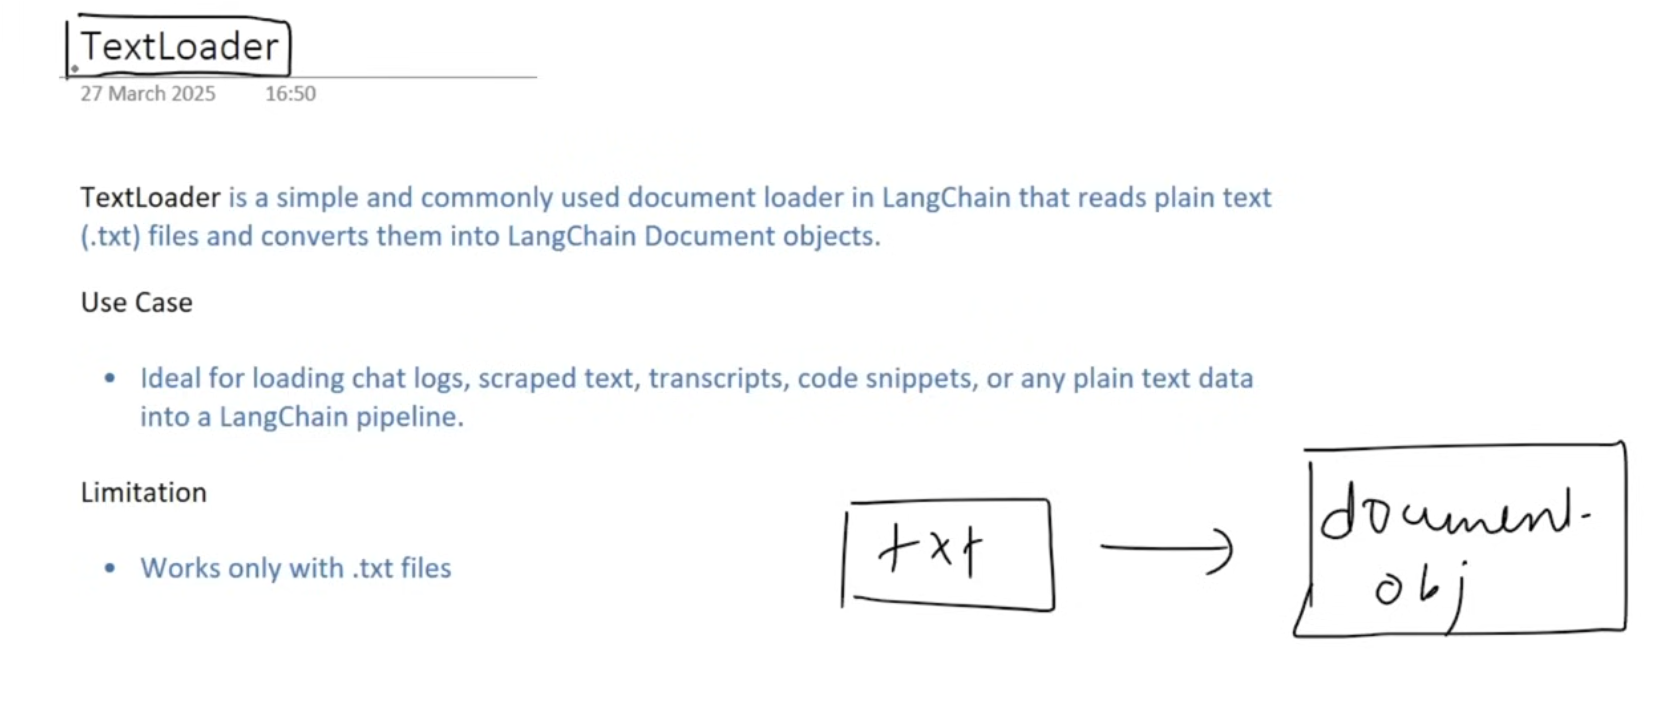

In [3]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader("cricket.txt")

docs = loader.load()

print(docs)

[Document(metadata={'source': 'cricket.txt'}, page_content='Beneath the sun or floodlight\'s gleam,\n\nCricket lives like a waking dream.\n\nA field of green, a willowed sound,\n\nWhere legends rise and tales are found.\n\nFrom dusty lanes where barefoot boys,\n\nChase every run with shrieks of joy,\n\nTo packed arenas roaring loud,\n\nThe game unites a global crowd.\n\nA coin is tossed, the captains stare,\n\nAs tension thickens in the air.\n\nBat or bowl? A choice so bold,\n\nA story new begins, retold.\n\nThe openers walk, calm yet brave,\n\nEach stride a wave upon the wave.\n\nThey face the ball with narrowed eyes,\n\nAs silence grips the watching skies.\n\nThe bowler runs, a rhythmic beat,\n\nLike thunder galloping on feet.\n\nA leather flash, a wooden crack—\n\nThe ball takes flight, then tumbles back.\n\nA flick through square, a drive through mid,\n\nA lofted shot the fielder missed.\n\nA single, double, sprint for three,\n\nThe crowd erupts in ecstasy.\n\nBut not for long—the 

In [4]:
print(type(docs))

<class 'list'>


In [5]:
print(len(docs))

1


In [ ]:
print(docs[0].page_content)

Beneath the sun or floodlight's gleam,

Cricket lives like a waking dream.

A field of green, a willowed sound,

Where legends rise and tales are found.

From dusty lanes where barefoot boys,

Chase every run with shrieks of joy,

To packed arenas roaring loud,

The game unites a global crowd.

A coin is tossed, the captains stare,

As tension thickens in the air.

Bat or bowl? A choice so bold,

A story new begins, retold.

The openers walk, calm yet brave,

Each stride a wave upon the wave.

They face the ball with narrowed eyes,

As silence grips the watching skies.

The bowler runs, a rhythmic beat,

Like thunder galloping on feet.

A leather flash, a wooden crack—

The ball takes flight, then tumbles back.

A flick through square, a drive through mid,

A lofted shot the fielder missed.

A single, double, sprint for three,

The crowd erupts in ecstasy.

But not for long—the trap is set,

The spinner loops, the pitch is wet.

A sudden turn, the bat’s deceived,

And timber flies like

In [9]:
print(docs[0].metadata)

{'source': 'cricket.txt'}


In [ ]:
from langchain_ollama import OllamaLLM
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

model = OllamaLLM(model="llama3.2")

prompt = PromptTemplate(
    template='Write a summary for the following poem - \n: {poem}',
    input_variables=['poem']
)

parser = StrOutputParser()

chain = prompt | model | parser

result = chain.invoke(
    {
        'poem': docs[0].page_content
    }
)
print(result)

This poem is an ode to the game of cricket, exploring its emotional, spiritual, and cultural significance. It celebrates the excitement, skill, and camaraderie that cricket embodies, describing moments of triumph, heartbreak, and suspense in vivid detail.

The poem also delves into the personal connections that fans make with the game, from childhood memories to adulthood, highlighting the role of cricket as a shared experience that transcends borders, cultures, and generations. It weaves together references to legendary players, matches, and venues, adding depth and richness to its narrative.

Throughout the poem, there's a focus on the transformative power of cricket, how it can bring people together, evoke strong emotions, and inspire heroism. The author skillfully conveys the sense of community that defines cricket fandom, showcasing how fans unite across differences and rivalries to share in the thrill of competition.

Ultimately, the poem concludes with an affirmation of the endu

<h1 style="color:rgb(255, 98, 0);">2. PyPDF Loader</h1>

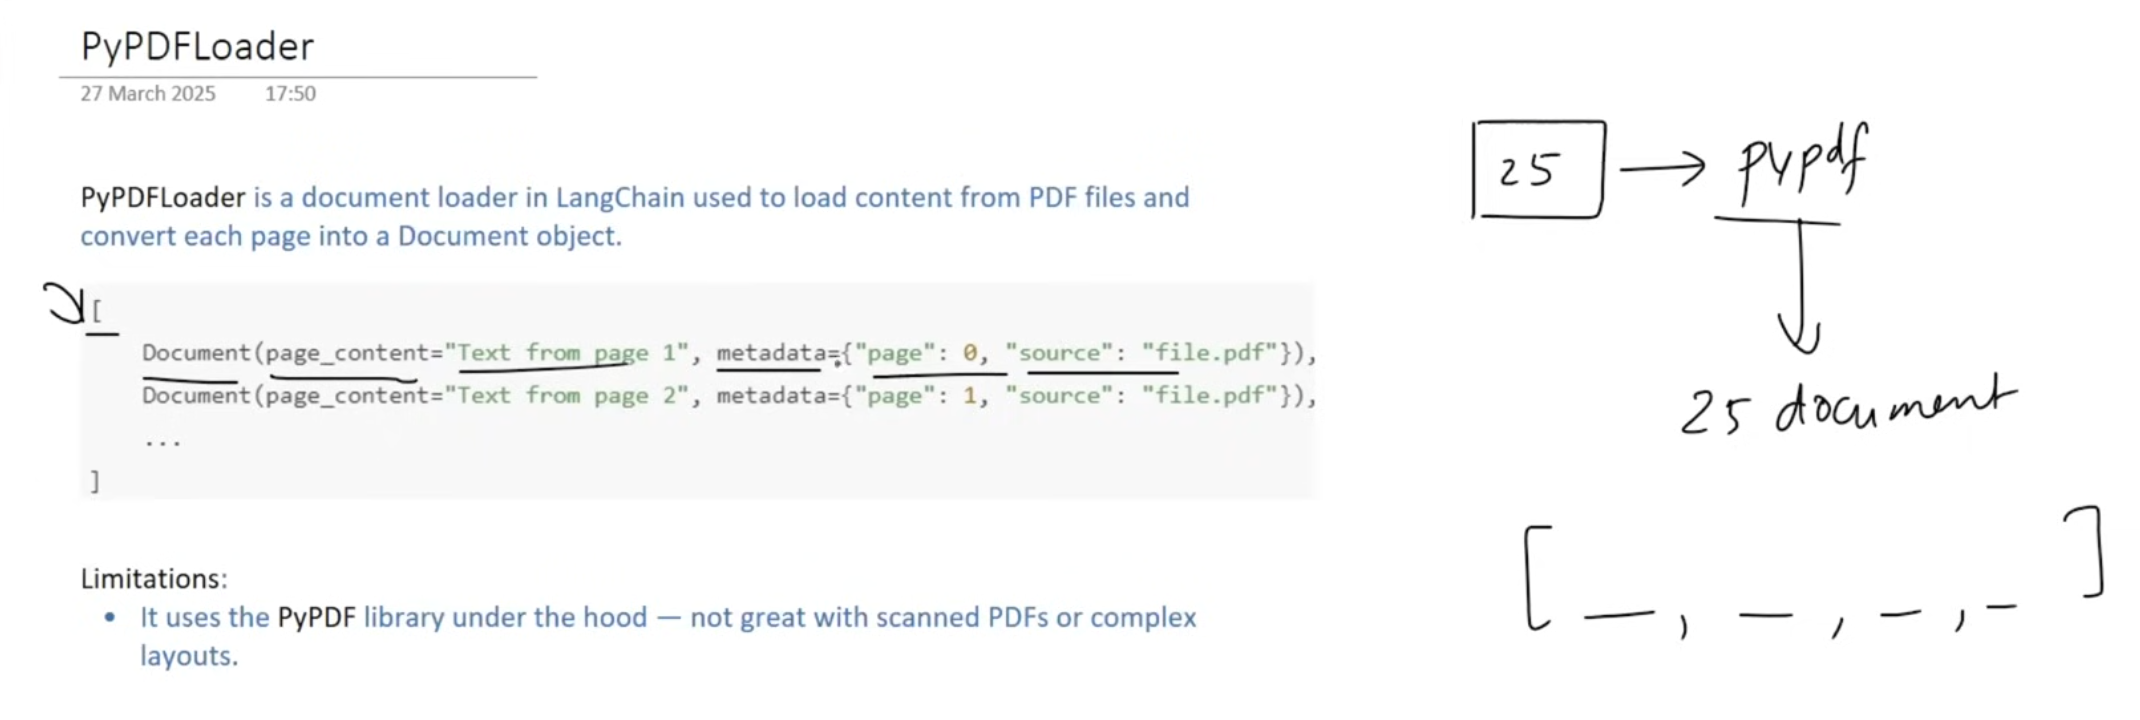

### 📄 PDF Loaders in LangChain

| **Loader**                  | **Use Case**                                                                 |
|----------------------------|------------------------------------------------------------------------------|
| **PyPDFLoader**            | ✅ General-purpose; best for simple PDFs with extractable text.              |
| **PDFMinerLoader**         | 📐 More control over text layout; good for structured or complex PDFs.       |
| **PyMuPDFLoader** (fitz)   | 🖼️ Handles images, metadata; better for scanned or visually rich PDFs.       |
| **PDFPlumberLoader**       | 📊 Accurate layout and table extraction; great for tabular PDFs.            |
| **UnstructuredPDFLoader**  | 🧠 Uses `unstructured` lib; best for messy, scanned, or image-heavy PDFs.    |
| **OnlinePDFLoader**        | 🌐 Load PDFs directly from URLs.                                             |

### ✅ When to Use What?

- **PyPDFLoader** → Fast and simple extraction from text-based PDFs.  
- **PDFMinerLoader** → For fine-grained layout control.  
- **PDFPlumberLoader** → When dealing with tables and accurate formatting.  
- **PyMuPDFLoader** → Useful for visual PDFs or when you need images & metadata.  
- **UnstructuredPDFLoader** → Great for OCR or poorly formatted documents.  
- **OnlinePDFLoader** → Use when loading PDFs from the web.



In [19]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("Types Of RAG.pdf")

docs = loader.load()

print(docs)

[Document(metadata={'source': 'Types Of RAG.pdf', 'page': 0}, page_content='@Bhavishya Pandit\nTypes \nof RAG25\n1 '), Document(metadata={'source': 'Types Of RAG.pdf', 'page': 1}, page_content='1. Standard RAG\nCombines retrieval with large\nlanguage models for accurate,\ncontext-aware responses.\nBreaks documents into chunks for\nefficient information retrieval.\nAims for 1-2 second response times\nfor real-time use.\nEnhances answer quality by\nleveraging external data sources.\n2. Corrective RAG\nFocuses on identifying and fixing\nerrors in generated responses.\nUses multiple passes to improve\noutputs based on feedback.\nAims for higher precision and\nuser satisfaction compared to\nstandard RAG.\nLeverages user feedback to\nenhance the correction process .\n@Bhavishya Pandit\n2'), Document(metadata={'source': 'Types Of RAG.pdf', 'page': 2}, page_content='3. Speculative RAG\nUses a small specialist model for\ndrafting and a larger generalist\nmodel for verification, ensuring\neffici

In [20]:
print(len(docs))

15


In [21]:
print(type(docs))

<class 'list'>


In [25]:
print(docs[1].page_content)
print(docs[1].metadata)

1. Standard RAG
Combines retrieval with large
language models for accurate,
context-aware responses.
Breaks documents into chunks for
efficient information retrieval.
Aims for 1-2 second response times
for real-time use.
Enhances answer quality by
leveraging external data sources.
2. Corrective RAG
Focuses on identifying and fixing
errors in generated responses.
Uses multiple passes to improve
outputs based on feedback.
Aims for higher precision and
user satisfaction compared to
standard RAG.
Leverages user feedback to
enhance the correction process .
@Bhavishya Pandit
2
{'source': 'Types Of RAG.pdf', 'page': 1}


<h1 style="color:rgb(255, 98, 0);">3. Directory Loader</h1>

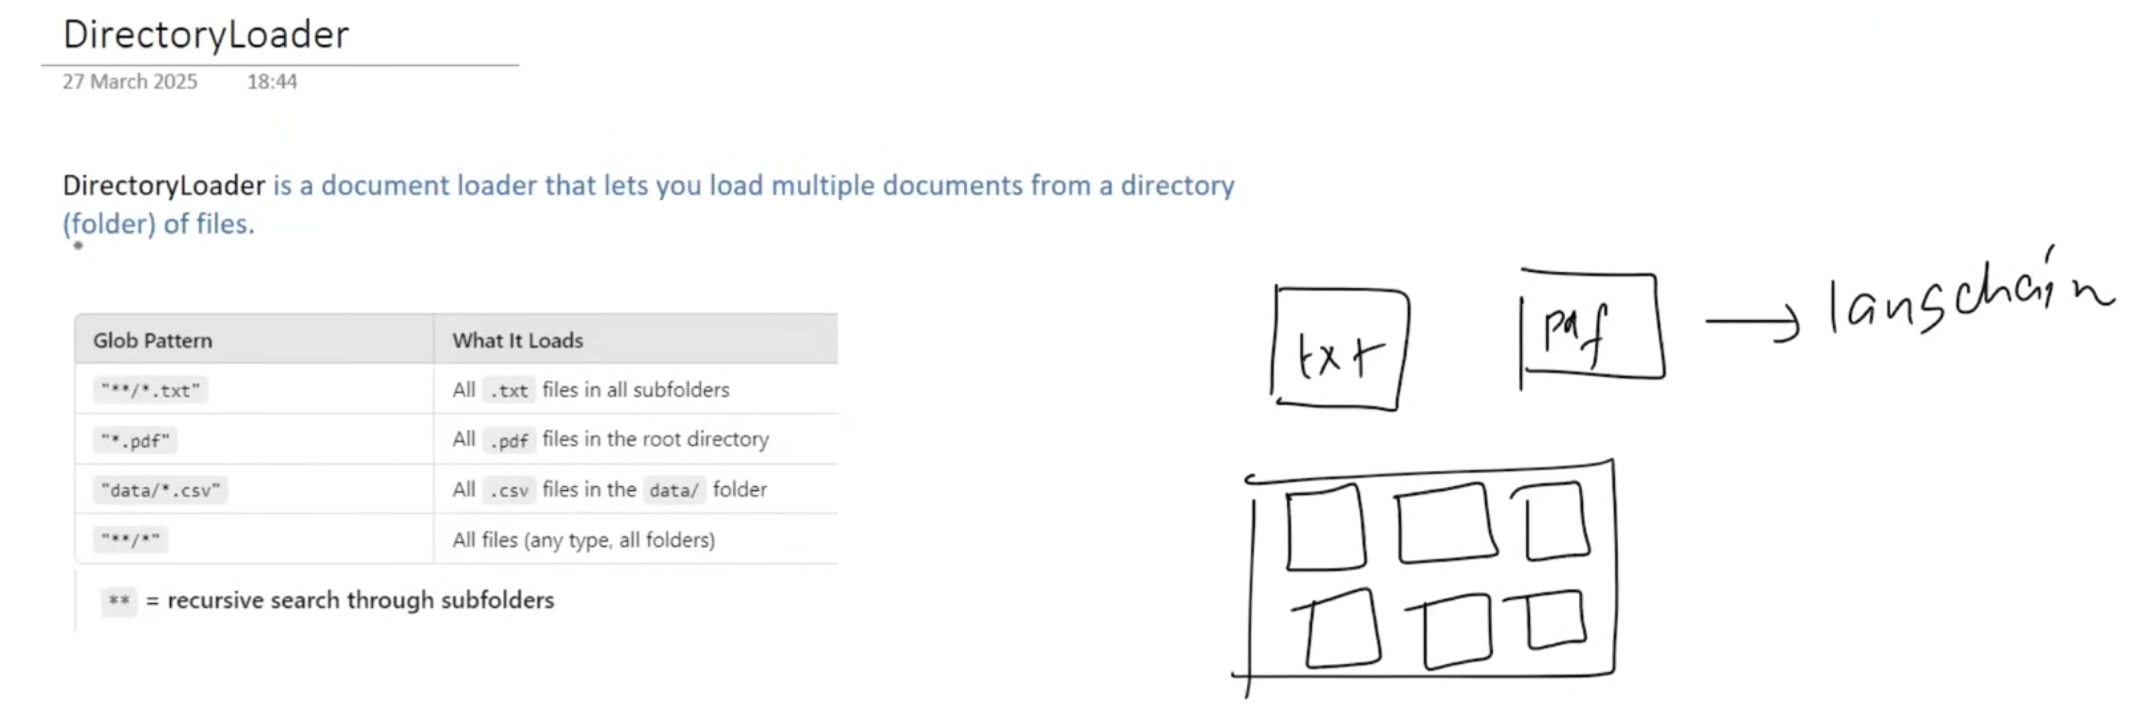

In [32]:
from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader

loader = DirectoryLoader(
    path="Docs",
    glob="*.pdf",
    loader_cls=PyPDFLoader
)

docs = loader.load()

print(len(docs))

103


In [28]:
docs[0].page_content

'BY  \nS T A N F O R D  U N I V E R S I T Y \nA N D \nM A S S A C H U S E T T S  I N S T I T U T E  O F  \nT E C H N O L O G Y \nAll Cheat Sheets  \n Machine Learning, Deep Learning,  \nArtificial Intelligence \nCOMPILED BY -  NIKHIL YADAV '

In [29]:
print(docs[0].metadata)

{'source': 'Docs/AI_ML_DL_cheetsheet.pdf', 'page': 0}


### ⚖️ `load()` vs `lazy_load()` in LangChain

| **Method**       | **Description**                                                                 |
|------------------|----------------------------------------------------------------------------------|
| `load()`         | 📦 Loads **all documents at once** into memory.                                 |
| `lazy_load()`    | 🧠 Loads documents **one at a time using a generator** (lazy evaluation).       |

### ✅ When to Use

- **Use `load()`**:
  - When the number of documents is **small to moderate**.
  - You want immediate access to all data.
  - Simpler and easier to work with.

- **Use `lazy_load()`**:
  - When dealing with **large files** or **memory constraints**.
  - You want to **stream/process documents one at a time**.
  - More memory-efficient for big data pipelines.



<h1 style="color:rgb(255, 98, 0);">4. WebBase Loader</h1>

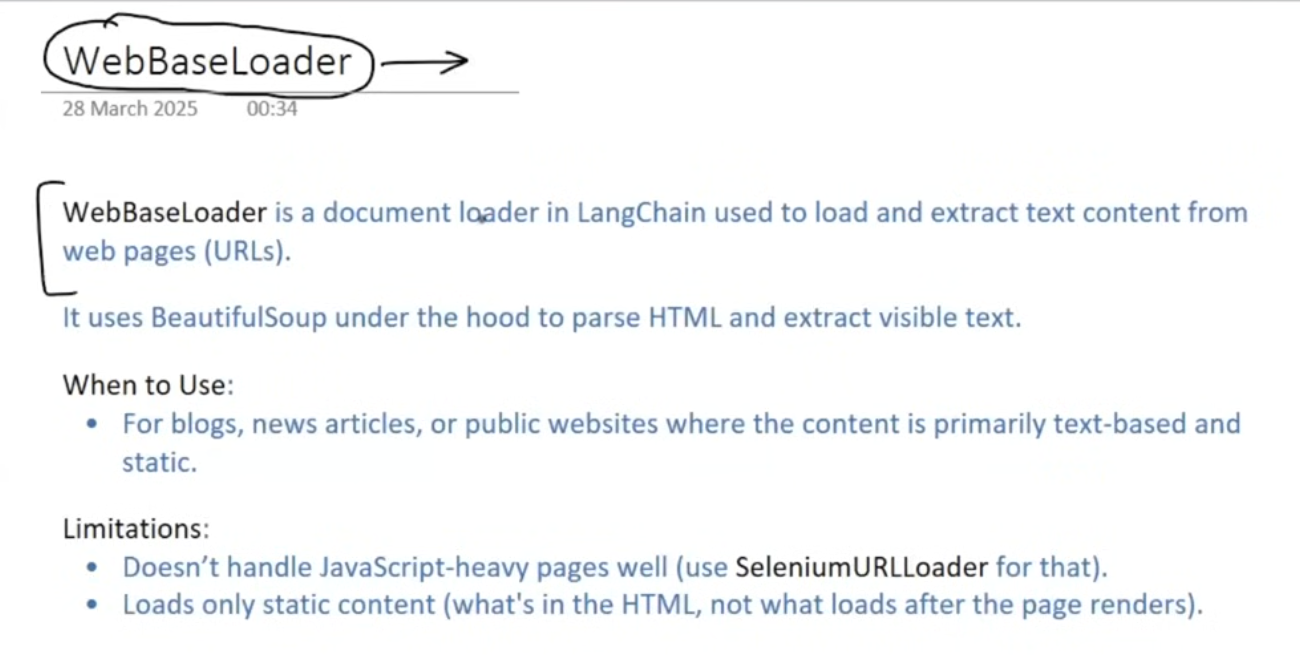

In [38]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_ollama import OllamaLLM
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

model = OllamaLLM(model="llama3.2")

prompt = PromptTemplate(
    template='Answer the following question \n {question} from the following text - \n {text}',
    input_variables=['question','text']
)

parser = StrOutputParser()

url = 'https://www.myntra.com/jackets/snitch/snitch-men-solid-relaxed-fit-cotton-denim-jacket/33326856/buy'
loader = WebBaseLoader(url)

docs = loader.load()

chain = prompt | model | parser

print(chain.invoke({'question':'What is the prodcut that we are talking about?', 'text':docs[0].page_content}))

The product being discussed is a Snitch Men Solid Relaxed Fit Cotton Denim Jacket.


<h1 style="color:rgb(255, 98, 0);">5. CSV Loader</h1>

In [39]:
from langchain_community.document_loaders import CSVLoader

loader = CSVLoader(file_path='Social_Network_Ads.csv')

docs = loader.load()

print(len(docs))
print(docs[1])

400
page_content='User ID: 15810944
Gender: Male
Age: 35
EstimatedSalary: 20000
Purchased: 0' metadata={'source': 'Social_Network_Ads.csv', 'row': 1}
